# Q2: Vision Language Models (VLMs) + Efficient Inference

# S1: VLM Anatomy

**Objective:** In this section, you will learn the anatomy of Vision-Language Models (VLMs), identify their core components, and practically explore how images are translated into tokens that a Large Language Model (LLM) can process.

## 1. Model Anatomy

A typical Vision-Language Model usually consists of three main components:

- **Vision Encoder:** A neural network (often a Vision Transformer or ViT) that processes the raw image to extract visual features.
- **Vision-Language Projector:** Linear layers or MLPs that map the extracted visual features into the same dimensional space as the text tokens.
- **Large Language Model:** The core LLM that processes the combined sequence of text and visual tokens to generate an output.

### Task 1.1: Load and Inspect the Model

Complete and run the code cell below to use the transformers library to load the Qwen/Qwen3.5-0.8B model and its processor, and print the underlying model architecture.


In [3]:
import torch
import gc
from transformers import AutoModelForMultimodalLM, AutoProcessor

# ==========================================
# 0. Hardware Detection & Memory Clearing
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
target_dtype = torch.float16 if device == "cuda" else torch.float32
target_device_map = "auto" if device == "cuda" else {"": "cpu"}

print(f"Hardware detected: Using {device.upper()} with dtype {target_dtype}")

if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()

model_id = "Qwen/Qwen3.5-0.8B"

# ==========================================
# 1. Load Model and Processor
# ==========================================
print(f"Loading base model: {model_id} ...")

model = AutoModelForMultimodalLM.from_pretrained(
    model_id,
    torch_dtype=target_dtype,
    device_map=target_device_map,
    trust_remote_code=True
)

processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code=True
)


Hardware detected: Using CPU with dtype torch.float32
Loading base model: Qwen/Qwen3.5-0.8B ...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [4]:
print("\nModel Architecture:")
print("-------------------")
print(model)


Model Architecture:
-------------------
Qwen3_5ForConditionalGeneration(
  (model): Qwen3_5Model(
    (visual): Qwen3_5VisionModel(
      (patch_embed): Qwen3_5VisionPatchEmbed(
        (proj): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 768)
      (rotary_pos_emb): Qwen3_5VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-11): 12 x Qwen3_5VisionBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (attn): Qwen3_5VisionAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (mlp): Qwen3_5VisionMLP(
            (linear_fc1): Linear(in_features=768, out_features=3072, bias=True)
            (linear_fc2): Linear(in_features=3072, out_features=768, bias=True)
          

**Question 1.1:** Inspect the printed model architecture layout above. Identify and write down the exact module or class names corresponding to the Vision Encoder, the Projector, and the Large Language Model components.

**Student's Answer:**


**Expected Answer for Instructor (Task 1.1 Evaluation):**

- **Vision Encoder:** The student should locate `Qwen3_5VisionModel`.
- **Projector:** The student should locate the `merger` module (specifically `Qwen3_5VisionPatchMerger`), noting that it projects the vision features down to the LLM's hidden size (1024).
- **Large Language Model:** The student should locate `Qwen3_5TextModel` containing the structural text decoding layers.

## 2. Baseline Inference

Let's test the model on real data to see how it performs. We will break this down into three steps: loading data, formatting the multimodal prompts, and generating the responses.

### Task 1.2a: Load and Explore the Dataset

Complete and run the code below to load the ScienceQA dataset and filter it for evaluation samples containing visual context.


In [29]:
from datasets import load_dataset

print("Loading ScienceQA dataset...")
dataset = load_dataset("derek-thomas/ScienceQA")

# Filter for image-based questions only
image_data = dataset["train"].filter(lambda x: x['image'] is not None)

# Select 3 diverse samples
sample_indices = [0, 12, 25]
selected_samples = [image_data[i] for i in sample_indices]

print(f"Dataset loaded! Successfully selected {len(selected_samples)} diverse samples for evaluation.")

Loading ScienceQA dataset...
Dataset loaded! Successfully selected 3 diverse samples for evaluation.


### Task 1.2b: Format the Multimodal Prompts

VLMs require structural preprocessing to combine image arrays and text strings into a unified sequence. Complete and run the cell below to apply the chat template and process the multimodal sequence for the selected evaluation samples.


In [6]:
!pip install qwen_vl_utils

In [30]:
from qwen_vl_utils import process_vision_info

prepared_samples = []

for sample in selected_samples:
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # Format the messages
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt},
            ]
        }
    ]

    # Apply chat template
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, chat_template_kwargs={"enable_thinking": False}
    )

    # Process visual information
    image_inputs, _ = process_vision_info(messages)

    # Finalize inputs for the model using explicit modality kwargs to enforce tensors
    inputs = processor(
        text=[text],
        images=image_inputs,
        text_kwargs={"return_tensors": "pt"},
        images_kwargs={"return_tensors": "pt"}
    ).to(device)

    # Pack components together for full contextual evaluation in the next step
    prepared_samples.append({
        "inputs": inputs,
        "image": sample["image"],
        "prompt": full_prompt,
        "ground_truth": ground_truth
    })

print(f"Successfully formatted {len(prepared_samples)} multimodal prompts ready for inference.")

Successfully formatted 3 multimodal prompts ready for inference.


### Task 1.2c: Generate and Decode

In this task, you will execute the baseline generation. Complete and run the loop below to feed the preprocessed inputs into the model, extract the newly generated IDs, and decode them into readable text answers.

**Note:** You must write your code to explicitly display the Image, the Text Prompt/Question, the Ground Truth Answer, and the generated Model Output sequentially for each sample. This is a mandatory step to directly assess and verify the VLM's inference capabilities.


In [10]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 4.2 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.3 MB 4.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.3 MB 5.0 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 5.1 MB/s eta 0:00:02
   --------------------- ------------------ 5.0/9.3 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 5.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 5.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 4.8 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? 


==================== PROCESSING SAMPLE 1 ====================


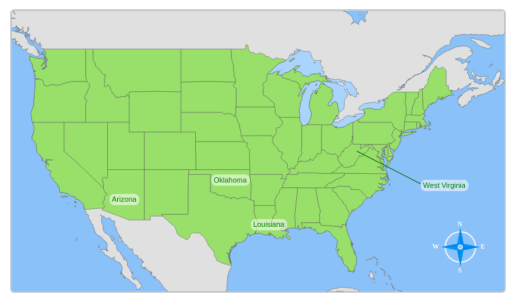

Question & Prompt:
Which of these states is farthest north?
Choices:
- West Virginia
- Louisiana
- Arizona
- Oklahoma
Answer concisely with the correct choice.

Ground Truth Answer: West Virginia
Model Output: West Virginia

==================== PROCESSING SAMPLE 2 ====================


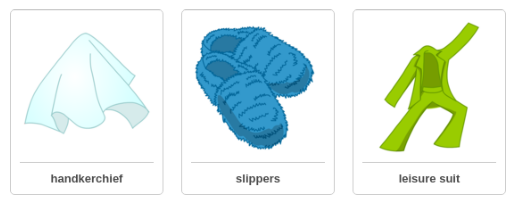

Question & Prompt:
Which property do these three objects have in common?
Choices:
- hard
- soft
- yellow
Answer concisely with the correct choice.

Ground Truth Answer: soft
Model Output: soft

==================== PROCESSING SAMPLE 3 ====================


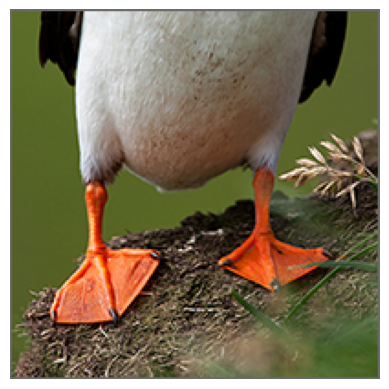

Question & Prompt:
Which animal's feet are also adapted for swimming?
Choices:
- blue-footed booby
- tokay gecko
Answer concisely with the correct choice.

Ground Truth Answer: blue-footed booby
Model Output: blue-footed booby


In [31]:
import matplotlib.pyplot as plt

model.eval()

for i, sample_data in enumerate(prepared_samples):
    print(f"\n==================== PROCESSING SAMPLE {i+1} ====================")

    # 1. Display the associated image context
    plt.imshow(sample_data["image"])
    plt.axis('off')
    plt.show()

    # 2. Print the textual question and choices
    print(f"Question & Prompt:\n{sample_data['prompt']}\n")

    # 3. Print the true reference answer
    print(f"Ground Truth Answer: {sample_data['ground_truth']}")

    inputs = sample_data["inputs"]
    with torch.no_grad():
        # Generate the tokens
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=True,
            temperature=0.7,
            top_p=0.80,
            top_k=20
        )

    # Trim the prompt tokens from the generated output
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    # Decode the tokens back to text
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    # 4. Print the final decoded model response
    print(f"Model Output: {output_text.strip()}")
    print("=" * 54)

## 3. Playing with Tokens: Analyzing the Input Sequence

When a VLM encounters an image, it converts the picture into a series of 'visual tokens' and integrates them with the text tokens, forming a single prompt for the LLM.

### Task 1.3: Structural Token Analysis

Complete the cell below to inspect the input_ids tensor generated from the last processed sample. Your task is to use this tensor to calculate the exact number of visual tokens and text tokens present in the sequence.



In [12]:
# Query the model configuration for the specific image token placeholder ID
image_token_id = model.config.image_token_id

# Extract total sequence length
total_token_count = inputs["input_ids"].shape[1]

# Count the occurrences of the image placeholder within the input tensor
visual_token_count = (inputs["input_ids"] == image_token_id).sum().item()

# Determine the remaining number of tokens allocated to text structures
text_token_count = total_token_count - visual_token_count

print(f"Image Placeholder Token ID: {image_token_id}")
print(f"Number of Visual Tokens: {visual_token_count}")
print(f"Number of Text Tokens: {text_token_count}")
print(f"Total Sequence Length: {total_token_count}")

Image Placeholder Token ID: 248056
Number of Visual Tokens: 312
Number of Text Tokens: 48
Total Sequence Length: 360


Question 1.3a (Empirical Analysis): Review the printed token counts from the code execution above. Calculate the exact percentage of the total input sequence length ($N$) that is occupied by the visual tokens versus the textual tokens. What does this distribution tell you about how a VLM allocates its processing capacity compared to a traditional text-only LLM?

**Student's Answer:**



**Question 1.3b (Mathematical Complexity Analysis):** Consider the standard computational cost formula per forward pass for a single Transformer processing an input sequence:

$$\text{Total FLOPs} = T \times (4nd^2 + 2n^2d + 2ndm)$$

Where:

- $n$ is the sequence length (total number of tokens).
- $d$ is the model's hidden embedding dimension size.
- $m$ is the intermediate dimension size of the MLP layer.
- $T$ is the number of transformer blocks/layers.

Based on this formula and the token counts you extracted in Task 1.3, identify which specific term inside the parentheses poses the greatest computational threat when shifting from a text-only LLM to a Vision-Language Model. Explain why processing visual data scales the computational overhead so aggressively.

**Student's Answer:**


**Expected Answer for Instructor (Task 1.3 Evaluation):**

- **Code Output Check:** The student must successfully display the correct `image_token_id` and the accurate count showing that visual tokens take up the vast majority of the total sequence length.
- **Question 1.3a Evaluation:** Students should calculate the percentage and realize that the model's context window is overwhelmingly dominated by the image placeholder patches, leaving much less room for text processing.
- **Question 1.3b Evaluation:** Students must point directly to the quadratic attention term, $2n^2d$. They should explain that because $n$ (sequence length) scales drastically due to the injection of hundreds or thousands of visual tokens per image, the $n^2$ scaling factor causes the total FLOP count to explode quadratically. This explains why VLMs demand vastly higher computational resources than standard text-only LLMs.

# S2: Dynamic Resolution and Efficient Inference

**Objective:** In this section, you will explore how Qwen processes images, manage memory and accelerate inference speed by controlling image resolution.

## 1. Dynamic Resolution Mechanism

Older Vision-Language Models required all input images to be resized or cropped to a fixed resolution before processing. Qwen utilizes a more advanced approach called Dynamic Resolution.

### Task 2.1: Documentation Review

Review the official documentation or technical reports for the Qwen-VL architecture (e.g., the [Qwen2-VL Paper](https://arxiv.org/abs/2409.12191) or [Qwen2.5-VL Blog Post](https://qwen.ai/blog?id=qwen2.5-vl)). Write a brief paragraph explaining how Qwen handles images of varying sizes and aspect ratios. How does it preserve the original image structure without forcing a rigid resize?

**Student's Answer:**



**Expected Answer for Instructor (Task 2.1 Evaluation):**

The student should explain that Qwen dynamically calculates a grid for the image based on its original aspect ratio and the allowed maximum pixels. It then divides the image into uniform blocks (patches). Instead of squashing or stretching the image to a fixed resolution, it maps these spatial patches into a sequence of tokens, allowing the model to process arbitrary resolutions and aspect ratios naturally.

## 2. Baseline Inference (High Resolution)

To measure the impact of resolution on speed and accuracy, we first need to establish a baseline. We will evaluate the model on 100 samples using its default, unrestricted resolution settings.

### Task 2.2a: Prepare the Evaluation Subset

Complete and run the cell below to randomly select 100 image-based questions from the ScienceQA dataset. Crucially, we extract these samples from the test split to prevent any data leakage during the training phase later.


In [13]:
import random
from datasets import load_dataset

print("Loading ScienceQA dataset...")
dataset = load_dataset("derek-thomas/ScienceQA")

# Extract strictly from the TEST split for evaluation
image_data = dataset["test"].filter(lambda x: x['image'] is not None)

# Set a fixed seed for reproducibility
random.seed(42)
eval_indices = random.sample(range(len(image_data)), 100)
eval_samples = [image_data[i] for i in eval_indices]

print(f"Successfully selected {len(eval_samples)} test samples for the baseline evaluation.")

Loading ScienceQA dataset...


Filter:   0%|          | 0/4241 [00:00<?, ? examples/s]

Successfully selected 100 test samples for the baseline evaluation.


### Task 2.2b: Run Baseline Evaluation

Complete the code below to run the inference loop on the 100 selected samples. We will use the standard processor from the previous section. The code includes a timer to track exactly how long the entire batch takes.


In [14]:
import time
import torch
from qwen_vl_utils import process_vision_info

model.eval()

correct_predictions_baseline = 0
start_time_baseline = time.time()

print("Starting Baseline Inference (High Resolution)... This may take a while.")

for i, sample in enumerate(eval_samples):
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt},
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, chat_template_kwargs={"enable_thinking": False}
    )
    image_inputs, _ = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        text_kwargs={"return_tensors": "pt"},
        images_kwargs={"return_tensors": "pt"}
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False, # Greedy decoding for more deterministic evaluation
            temperature=None,
            top_p=None
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()

    if ground_truth.lower() in output_text.lower():
        correct_predictions_baseline += 1

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/100 samples...")

end_time_baseline = time.time()
baseline_duration = end_time_baseline - start_time_baseline
baseline_accuracy = (correct_predictions_baseline / len(eval_samples)) * 100

print("\n--- Baseline Results ---")
print(f"Total Time: {baseline_duration:.2f} seconds")
print(f"Accuracy: {baseline_accuracy:.2f}%")

Starting Baseline Inference (High Resolution)... This may take a while.
Processed 10/100 samples...
Processed 20/100 samples...
Processed 30/100 samples...
Processed 40/100 samples...
Processed 50/100 samples...
Processed 60/100 samples...
Processed 70/100 samples...
Processed 80/100 samples...
Processed 90/100 samples...
Processed 100/100 samples...

--- Baseline Results ---
Total Time: 503.72 seconds
Accuracy: 59.00%


## 3. Low-Resolution Inference

Now, we will restrict the image resolution before passing it to the model. By setting a specific `max_pixels` limit, we force the processor to generate fewer visual patches.

### Task 2.3: Re-initialize Processor and Re-evaluate

Run the cell below. It creates a new processor with a strict pixel limit and evaluates the exact same 100 samples. Observe how the time and accuracy metrics change.

(Note: The minimum acceptable resolution for `max_pixels` in this exercise is 32 * 28 * 28.)


In [15]:
from transformers import AutoProcessor

# 1. Initialize a new processor with constrained resolution
low_res_pixels = 32 * 28 * 28  # Change this if you wish to experiment, but keep it >= 32*28*28
print(f"Loading constrained processor (max_pixels = {low_res_pixels})...")

processor_low_res = AutoProcessor.from_pretrained(
    model_id,
    max_pixels=low_res_pixels,
    trust_remote_code=True
)

correct_predictions_low_res = 0
start_time_low_res = time.time()

print("Starting Low-Resolution Inference...")

for i, sample in enumerate(eval_samples):
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt},
            ]
        }
    ]

    text = processor_low_res.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, chat_template_kwargs={"enable_thinking": False}
    )
    image_inputs, _ = process_vision_info(messages)

    inputs = processor_low_res(
        text=[text],
        images=image_inputs,
        text_kwargs={"return_tensors": "pt"},
        images_kwargs={"return_tensors": "pt"}
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            temperature=None,
            top_p=None
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor_low_res.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()

    if ground_truth.lower() in output_text.lower():
        correct_predictions_low_res += 1

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/100 samples...")

end_time_low_res = time.time()
low_res_duration = end_time_low_res - start_time_low_res
low_res_accuracy = (correct_predictions_low_res / len(eval_samples)) * 100

print("\n--- Low-Resolution Results ---")
print(f"Total Time: {low_res_duration:.2f} seconds")
print(f"Accuracy: {low_res_accuracy:.2f}%")

# Print Comparison
print("\n--- Final Comparison ---")
print(f"Time Saved: {baseline_duration - low_res_duration:.2f} seconds")
print(f"Accuracy Difference: {low_res_accuracy - baseline_accuracy:.2f}%")

Loading constrained processor (max_pixels = 25088)...
Starting Low-Resolution Inference...
Processed 10/100 samples...
Processed 20/100 samples...
Processed 30/100 samples...
Processed 40/100 samples...
Processed 50/100 samples...
Processed 60/100 samples...
Processed 70/100 samples...
Processed 80/100 samples...
Processed 90/100 samples...
Processed 100/100 samples...

--- Low-Resolution Results ---
Total Time: 282.55 seconds
Accuracy: 50.00%

--- Final Comparison ---
Time Saved: 221.17 seconds
Accuracy Difference: -9.00%


## 4. Mathematical Complexity Analysis

You should have noticed a difference in execution time and perhaps accuracy between the baseline and the low-resolution evaluation. Let's analyze exactly why this happens.

### Task 2.4: Comparative and Root Cause Analysis

First, create a simple chart or table (you can use Python or write it directly in your text answer) comparing the execution time and accuracy between the Baseline (High Resolution) and the Low-Resolution inference.

Based on your comparison:

1. **Accuracy Change:** How did the accuracy change? If there was a drop in accuracy, was it severe (causing the model to completely lose its ability to answer correctly), or was it minimal? What conclusion can you draw from this regarding the model's visual reasoning capabilities at lower resolutions?

2. **Time Change:** Recalling the Total FLOPs formula from the previous section, explain the exact reason for the change in execution time. Why does reducing the image resolution lead to an increase in inference speed?

**Student's Answer:**


**Expected Answer for Instructor (Task 2.4 Evaluation):**

- **Accuracy Change:** The student should observe how the accuracy changed. Usually, for simple QA datasets, any drop is minimal, showing that the model can still understand core visual concepts even with fewer patches. If it's minimal, they should conclude that high resolution is often redundant for simple reasoning tasks.

- **Time Change:** The student must explain that reducing the image resolution directly decreases the number of visual patches generated, which strictly reduces the total sequence length ($n$). Because the computational complexity of the Attention layer is $O(n^2)$ (as shown by the $2n^2d$ term from the previously discussed FLOPs formula), reducing $n$ lowers the floating-point operations (FLOPs) exponentially, not linearly. This massive drop in matrix multiplications is what causes the speedup during inference.

---

**Important Notice for the Next Section**

In the upcoming section (Section 3), we plan to fine-tune the model on this dataset. Because training a model requires significantly more memory (RAM/VRAM) to store gradients compared to simple inference, you are highly likely to encounter Out of Memory (OOM) errors if you attempt to train on high-resolution images.

To bypass this hardware limitation, we will be forced to decrease the image resolution during the fine-tuning process (e.g., using the `max_pixels = 32 * 28 * 28` setting).

**Crucial Note:** For your final evaluation at the end of Section 3 to be scientifically valid, the restricted resolution you utilize here in Task 2.3 must be exactly the same as the resolution you will use during the fine-tuning phase. This ensures a strictly accurate comparison between the pre-trained and fine-tuned models.

# S3: Supervised Fine-Tuning (with LoRA)

**Objective:** In this section, you will implement Low-Rank Adaptation (LoRA) to fine-tune the Qwen3.5 0.8B model. You will format multimodal data for training, configure memory-efficient training parameters, and evaluate the final fine-tuned model against your previous baseline.

## 1. Preparing the Training Data

To train the model, we need to convert the raw dataset into the exact chat structure the model expects.

### Task 3.1: Data Formatting and Structure

Complete the code below to extract a 1,000-sample subset from the ScienceQA dataset for training. Crucially, ensure this subset strictly contains image-based questions, as our goal is to train the visual reasoning capabilities of the model. You must write the formatting logic to structure the prompt.


In [16]:
import random
from datasets import load_dataset

print("Loading training dataset...")
dataset = load_dataset("derek-thomas/ScienceQA")

# Filter for image-based questions only (extracting from the TRAIN split)
train_image_data = dataset["train"].filter(lambda x: x['image'] is not None)

# 1. Select a subset of 1000 samples for training
random.seed(42)
train_indices = random.sample(range(len(train_image_data)), 1000)
train_subset = [train_image_data[i] for i in train_indices]

print(f"Selected {len(train_subset)} image-based samples for training.")

formatted_train_data = []

# 2. Format the data into the chat template structure
for sample in train_subset:
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # Define the target output
    structured_answer = ground_truth

    # Build the messages dictionary
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt},
            ]
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": structured_answer}
            ]
        }
    ]

    formatted_train_data.append({"messages": messages})

print("Data formatting complete. Sample structure:")
print(formatted_train_data[0]["messages"][1])

Loading training dataset...
Selected 1000 image-based samples for training.
Data formatting complete. Sample structure:
{'role': 'assistant', 'content': [{'type': 'text', 'text': 'Gymnothorax funebris'}]}


## 2. LoRA Configuration for VLMs

Fine-tuning an entire Vision-Language Model on standard hardware is extremely difficult due to massive memory requirements. We will use the `peft` library to apply Low-Rank Adaptation (LoRA), which freezes the base model and only trains a tiny set of injected weight matrices.

### Task 3.2: Configure PEFT

Review the Qwen3.5 architecture and standard LoRA practices. You need to identify which specific layers within the Large Language Model component should be targeted for adaptation. Do not target the Vision component layers.


In [17]:
!pip install -U "torchao>=0.16.0"

In [18]:
from peft import LoraConfig, get_peft_model

# Define the optimal LoRA parameters
lora_r = 16
lora_alpha = 32
target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "in_proj_qkv", "out_proj", "gate_proj", "up_proj", "down_proj"]

peft_config = LoraConfig(
    r=lora_r,
    lora_alpha=lora_alpha,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Apply the LoRA configuration using get_peft_model
model = get_peft_model(model, peft_config)

print("LoRA parameters configured and adapters applied to the model.")
model.print_trainable_parameters()

LoRA parameters configured and adapters applied to the model.
trainable params: 9,338,880 || all params: 862,324,800 || trainable%: 1.0830


## 3. The Training Loop

We will use Hugging Face's `Trainer` mapped for VLMs to handle the training loop. Because training memory footprint is heavily dependent on sequence length, we must strictly manage hardware constraints. To make the process clear, we will break the training setup into three smaller steps.

### Task 3.3a: Setup the Processor and Data Collator

Run the cell below to load our restricted-resolution processor and define a custom `DataCollator` that processes multimodal inputs dynamically during training.


In [19]:
import torch
from transformers import AutoProcessor
from qwen_vl_utils import process_vision_info

# --- Crucial Resolution Constraint ---
# We must use the low-resolution processor from Section 2 (e.g., 32 * 28 * 28)
low_res_pixels = 32 * 28 * 28
processor_train = AutoProcessor.from_pretrained(model_id, max_pixels=low_res_pixels, trust_remote_code=True)

# Define a custom data collator to process the multimodal inputs on the fly
def multimodal_data_collator(features):
    texts = []
    images = []

    for feature in features:
        messages = feature["messages"]
        text = processor_train.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        image_inputs, _ = process_vision_info(messages)
        texts.append(text)
        if image_inputs is not None:
            images.extend(image_inputs)

    # Process batch
    batch = processor_train(
        text=texts,
        images=images if len(images) > 0 else None,
        padding=True,
        text_kwargs={"return_tensors": "pt"},
        images_kwargs={"return_tensors": "pt"}
    )

    # For causal LM, labels are typically the same as input_ids (shifted internally by the model)
    batch["labels"] = batch["input_ids"].clone()
    return batch

print("Data collator successfully defined.")

Data collator successfully defined.


### Task 3.3b: Configure Training Arguments

The acceptable training configurations are specified within the code comments below. If your hardware encounters memory limitations (such as Out of Memory errors) or exceptionally slow training times, you should lower these parameters accordingly to successfully complete the fine-tuning process. Run the cell below to configure them.




In [23]:
from transformers import TrainingArguments

# Configure the Training Arguments
training_args = TrainingArguments(
    output_dir="./qwen_vlm_lora_output",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1, # Reduce to 1 if training is exceptionally slow on your hardware
    learning_rate=1e-4,
    fp16=True if device == "cuda" else False, # Use mixed precision if on GPU
    logging_steps=10,
    save_strategy="epoch",
    remove_unused_columns=False, # Crucial constraint for multimodal trainers
    report_to="none"
)

print("Training arguments successfully configured.")

Training arguments successfully configured.


### Task 3.3c: Initialize Trainer and Execute

Run the cell below to piece everything together into the `Trainer` and start the Fine-Tuning process.


In [24]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=formatted_train_data,
    data_collator=multimodal_data_collator,
)

print("Starting the Fine-Tuning process...")
trainer.train()

# Save the final LoRA adapter weights
trainer.save_model("./qwen_vlm_lora_final")
print("Training complete and LoRA weights successfully saved!")

Starting the Fine-Tuning process...
{'loss': '1.696', 'grad_norm': '2.921', 'learning_rate': '9.91e-05', 'epoch': '0.01'}
{'loss': '1.566', 'grad_norm': '5.685', 'learning_rate': '9.81e-05', 'epoch': '0.02'}
{'loss': '1.244', 'grad_norm': '3.945', 'learning_rate': '9.71e-05', 'epoch': '0.03'}
{'loss': '1.35', 'grad_norm': '4.76', 'learning_rate': '9.61e-05', 'epoch': '0.04'}
{'loss': '1.339', 'grad_norm': '6.285', 'learning_rate': '9.51e-05', 'epoch': '0.05'}
{'loss': '1.413', 'grad_norm': '3.116', 'learning_rate': '9.41e-05', 'epoch': '0.06'}
{'loss': '1.294', 'grad_norm': '6.415', 'learning_rate': '9.31e-05', 'epoch': '0.07'}
{'loss': '1.51', 'grad_norm': '4.512', 'learning_rate': '9.21e-05', 'epoch': '0.08'}
{'loss': '1.31', 'grad_norm': '3.649', 'learning_rate': '9.11e-05', 'epoch': '0.09'}
{'loss': '1.521', 'grad_norm': '3.476', 'learning_rate': '9.01e-05', 'epoch': '0.1'}
{'loss': '1.258', 'grad_norm': '2.515', 'learning_rate': '8.91e-05', 'epoch': '0.11'}
{'loss': '1.307', 'grad

## 4. Secondary Evaluation

With the model fine-tuned, it is time to measure the impact of our training. We will evaluate the fine-tuned model using the exact same evaluation dataset and settings from Section 2.

### Task 3.4: Evaluate the Fine-Tuned Model

Run the exact same 100 evaluation samples from Task 2.2 using the newly fine-tuned model and the restricted low-resolution processor.



In [25]:
import time

model.eval()

correct_predictions_ft = 0
start_time_ft = time.time()

print("Starting Evaluation on Fine-Tuned Model...")

# eval_samples is the list of 100 test samples generated in Section 2
for i, sample in enumerate(eval_samples):
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt},
            ]
        }
    ]

    text = processor_train.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, chat_template_kwargs={"enable_thinking": False}
    )
    image_inputs, _ = process_vision_info(messages)

    inputs = processor_train(
        text=[text],
        images=image_inputs,
        text_kwargs={"return_tensors": "pt"},
        images_kwargs={"return_tensors": "pt"}
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            temperature=None,
            top_p=None
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor_train.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()

    # Evaluation logic: Check if ground truth is in the text
    if ground_truth.lower() in output_text.lower():
        correct_predictions_ft += 1

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/100 samples...")

end_time_ft = time.time()
ft_duration = end_time_ft - start_time_ft
ft_accuracy = (correct_predictions_ft / len(eval_samples)) * 100

print("\n--- Fine-Tuned Model Results ---")
print(f"Total Time: {ft_duration:.2f} seconds")
print(f"Accuracy: {ft_accuracy:.2f}%")

Starting Evaluation on Fine-Tuned Model...
Processed 10/100 samples...
Processed 20/100 samples...
Processed 30/100 samples...
Processed 40/100 samples...
Processed 50/100 samples...
Processed 60/100 samples...
Processed 70/100 samples...
Processed 80/100 samples...
Processed 90/100 samples...
Processed 100/100 samples...

--- Fine-Tuned Model Results ---
Total Time: 227.19 seconds
Accuracy: 70.00%


# S4: Critical Analysis
---

### Task 4.1: The Tripartite Trade-off

Throughout this exercise, you have gathered metrics for three distinct states of the model. Fill in the comparison table below with the data you collected:

| Model State | Resolution (max_pixels) | Total Inference Time (s) | Accuracy (%) |
| --- | --- | --- | --- |
| **A) Baseline (High Res)** | Default (Unrestricted) | 503 | 59.0  |
| **B) Baseline (Low Res)** | 32 * 28 * 28 | 281 | 50.0 |
| **C) Fine-Tuned (Low Res)** | 32 * 28 * 28 | 227 | 70.0 |

Based on the data in your table, analyze the "Speed-Accuracy Trade-off." Did the computational time and effort spent fine-tuning the model in Section 3 justify the final inference speed and accuracy achieved in state (C)?

**Student's Answer:**


**Expected Answer for Instructor (Task 4.1 Evaluation):**
The student should fill the table correctly based on their previous outputs. They should observe that State (B) drastically reduced inference time compared to State (A), but at the cost of accuracy. State (C) should show an inference time identical to State (B), but with an accuracy that has bounced back (approaching or even exceeding State A). The student must logically conclude that the SFT training cost is a one-time investment that pays off by permanently providing high accuracy at high inference speeds, effectively breaking the standard speed-accuracy trade-off for this specific dataset.

---

### Task 4.2: Understanding Visual Redundancy
Look at your table from Task 4.1 and compare the rate of change in resolution versus the rate of change in accuracy when moving from State (A) to State (B). 

In machine learning, this specific behavior is related to the concept of data "redundancy." Based on your results, explain what visual redundancy means. Why can a model still logically process an image after losing a massive percentage of its visual patches, whereas dropping the exact same percentage of words from a text prompt would completely destroy its meaning?

**Student's Answer:**



**Expected Answer for Instructor (Task 4.2 Evaluation):**
The student should first point out that the accuracy drop was much less severe than the time/FLOPs drop. They should explain that adjacent pixels/patches in an image often contain identical or highly correlated information (e.g., a large patch of blue sky or a blank wall). Removing many of them reduces resolution but preserves the global shape and context. In contrast, human language is highly dense; every word carries unique weight. Dropping a single critical word (like "not") or randomly dropping 80% of text tokens completely destroys the semantic meaning of a sentence.

---

### Task 4.3: Exploring the Frontiers of Efficiency

In this exercise, we relied heavily on "Dynamic Resolution Reduction" to fit the VLM inference and training onto constrained hardware. However, this is just one approach in the broader field of efficient AI.

Research the current literature on Large Vision-Language Models. Identify and name at least **two other techniques** used to accelerate inference and reduce memory (VRAM) consumption. Provide a concise, one-sentence explanation of the core mechanism for each technique.

**Student's Answer:**


**Expected Answer for Instructor (Task 4.3 Evaluation):**
The student must identify at least two valid techniques. Common expected answers include:

1. **Quantization (e.g., QLoRA, AWQ, GPTQ):** Reducing the precision of the model's numerical weights (e.g., from 16-bit floating-point to 4-bit integers) to save memory and increase matrix multiplication speed.
2. **Token Merging (ToMe):** Dynamically identifying and combining highly similar visual tokens in the middle layers of the vision encoder to reduce the sequence length during the forward pass.
3. **KV Caching:** Storing the Key and Value matrices of previously computed tokens in memory so they do not need to be recomputed for every new token generated during text decoding.

---

### Task 4.4: Task-Specific Resolution Sensitivity
In our experiment, you saw how reducing the resolution affected the accuracy on the ScienceQA dataset. Do you think this result would be the same for all types of visual tasks? 

Compare the ScienceQA dataset to a dataset focused on reading dense charts, complex graphs, or document text (e.g., ChartQA or DocVQA). How would extreme resolution reduction affect the accuracy in those cases, and why? 

*(Note: You do not need to write code or run any tests for this question. Just provide your analytical opinion).*

**Student's Answer:**





**Expected Answer for Instructor (Task 4.4 Evaluation):**
The student should argue that the impact of resolution reduction is highly dependent on the dataset. ScienceQA primarily requires macroscopic visual understanding (e.g., identifying animals, general objects, or weather conditions) where coarse, low-resolution patches are sufficient. In contrast, ChartQA or DocVQA rely heavily on high-frequency, fine-grained details (reading small text, distinguishing thin lines, or identifying exact data points). Extreme resolution reduction on these datasets would irreversibly destroy the critical information needed to answer the prompt, leading to a catastrophic and unrecoverable drop in accuracy.